In [1]:
import pandas as pd 

In [2]:
import os

print(os.getcwd())

C:\Users\deeks\Documents\churn-prediction\data


In [3]:
os.listdir()

['.ipynb_checkpoints', '01_eda.ipynb', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [4]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [6]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df


In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df['Churn'].value_counts()

In [ ]:
df.isnull().sum()

In [ ]:
df.describe()

In [ ]:
df['TotalCharges'].dtype

In [ ]:
df['Contract']

In [8]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [9]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [10]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [11]:
df.groupby('Contract')['Churn'].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

In [12]:
import matplotlib.pyplot as plt

<Axes: xlabel='Contract'>

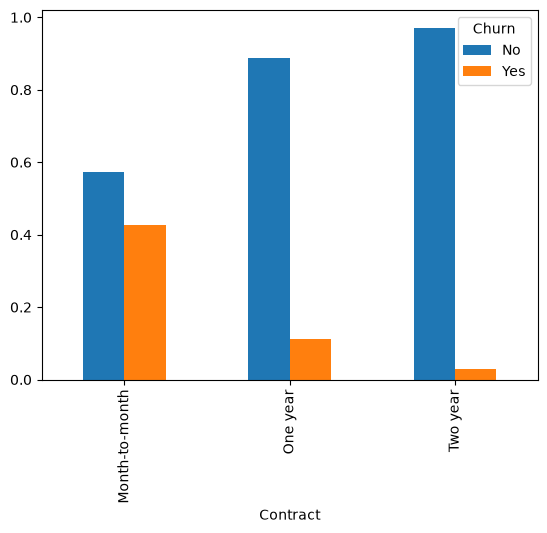

In [13]:
df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().plot(kind ='bar')

df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().plot(kind='bar')
plt.title('Churn Rate by Contract Type')
plt.show()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['customerID'].nunique()

7043

## EDA Summary
- Dataset has 7043 rows, 21 columns
- Churn distribution: ~73% No, ~27% Yes (imbalanced)
- TotalCharges loaded as object due to blank values in ~11 rows (0-tenure customers)
- Month-to-month contracts show significantly higher churn rate than 1-2 year contracts
- No duplicate customer IDs found

day 3 cleaning 

In [16]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

In [17]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [18]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [19]:
df.drop('customerID' ,axis=1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [20]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

In [21]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [22]:
df['Partner']=df['Partner'].map({'Yes':1,'No':0})

In [23]:
df['Partner'].value_counts()

Partner
0    3641
1    3402
Name: count, dtype: int64

In [24]:
df['Dependents']=df['Dependents'].map({'Yes':1,'No':0})

In [25]:
df['PhoneService']=df['PhoneService'].map({'Yes':1,'No':0})

In [26]:
df['PaperlessBilling']=df['PaperlessBilling'].map({'Yes':1,'No':0})

In [27]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [28]:
df['OnlineSecurity'].unique()


<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [29]:
df=pd.get_dummies(df , columns = ['Contract', 'InternetService', 'PaymentMethod', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'],drop_first=True)

In [30]:
df.shape

(7043, 32)

In [31]:
df.dtypes

customerID                                   str
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
Contract_One year                           bool
Contract_Two year                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
PaymentMethod_Credit card (automatic)       bool
PaymentMethod_Electronic check              bool
PaymentMethod_Mailed check                  bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
OnlineSecurity_No in

In [34]:
from sklearn.model_selection import train_test_split

In [36]:
 X= df.drop('Churn' , axis = 1)

In [38]:
Y = df['Churn']


In [39]:
X_train , X_test , Y_train , Y_test = train_test_split(
    X , Y,
    test_size=0.2,
    random_state=42,
    stratify=Y)

In [41]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
Y_train.to_csv('Y_train.csv', index=False)
Y_test.to_csv('Y_test.csv', index=False)

## Day 3 Summary
- Fixed TotalCharges dtype (text → float64), filled ~11 blank values with 0
- Dropped customerID (no predictive value)
- Converted Churn and binary Yes/No columns to 0/1
- One-hot encoded multi-category columns (Contract, InternetService, PaymentMethod, etc.)
- Final shape: X_train (rows, cols), X_test (rows, cols)
- Train/test split: 80/20, stratified on Churn